# Tutorial: Why Scaling and Normalization Matter in Regression

Feature scaling is just as important in regression as it is in classification—especially for models that use:

- **Distances**: K-Nearest Neighbors regression
- **Margins / kernels**: Support Vector Regression (SVR)
- **Regularization**: Ridge and Lasso regression
- **Gradient-based optimization**: neural networks and some iterative solvers

This tutorial compares regression performance with and without scaling.

We will create a dataset where features represent measurements in very different units:

- one feature might be measured in fractions,
- another in meters,
- another in thousands of dollars.

---
## 1,2. Imports and create regression data with differently scaled features

First, generate data where all original features have similar ranges. Then we artificially change their units.

In [9]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=1200,
    n_features=6,
    n_informative=6,
    noise=20,
    random_state=42
)

feature_names = [
    "temperature",
    "distance_km",
    "income",
    "population",
    "ratio",
    "area"
]

X = pd.DataFrame(X, columns=feature_names)

# Pretend that each feature uses a different real-world unit.
X["temperature"] *= 10       # small numerical scale

dist_min = min(X["distance_km"])
X["distance_km"] -= dist_min
X["distance_km"] *= 100

income_min = min(X["income"])
X["income"] -= income_min
X["income"] *= 1_000

pop_min = min(X["population"])
X["population"] -= pop_min
X["population"] *= 100_000    # extremely large numerical scale

X["ratio"] *= 0.1

area_min = min(X["area"])
X["area"] -= area_min
X["area"] *= 500

feature_ranges = pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "range": X.max() - X.min()
})

print(feature_ranges.round(2))


               min        max      range
temperature -30.20      32.43      62.63
distance_km   0.00     631.93     631.93
income        0.00    6701.27    6701.27
population    0.00  639332.41  639332.41
ratio        -0.32       0.39       0.71
area          0.00    3092.12    3092.12


Notice how `population` is numerically much larger than the other features.

For a distance-based model, this can become a major problem: distances will be dominated by that one large feature.

---

## 3. Split into training and test data



In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

---

## 4. A helper function for regression metrics

We will evaluate each model using:

- **MAE**: Mean Absolute Error — lower is better
- **RMSE**: Root Mean Squared Error — lower is better
- **R² score**: proportion of target variation explained — closer to `1` is better


In [3]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate_regression(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    return {
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": root_mean_squared_error(y_test, predictions),
        "R2": r2_score(y_test, predictions)
    }

---

# Part 1: KNN Regression

K-Nearest Neighbors regression predicts a target using the values of nearby data points.

Because “nearby” means **nearby in feature space**, scaling is extremely important.

---

## 5. Compare KNN with and without scaling



In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR


knn_models = {
    "No scaling": KNeighborsRegressor(n_neighbors=10),

    "StandardScaler": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=10))
    ]),

    "MinMaxScaler": Pipeline([
        ("scaler", MinMaxScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=10))
    ])
}

knn_results = {}

for name, model in knn_models.items():
    knn_results[name] = evaluate_regression(
        model,
        X_train, X_test,
        y_train, y_test
    )

knn_results_df = pd.DataFrame(knn_results).T
print(knn_results_df.round(3))

                    MAE     RMSE     R2
No scaling      118.235  146.840  0.080
StandardScaler   37.874   50.354  0.892
MinMaxScaler     37.367   49.380  0.896


---

## 6. Plot KNN performance


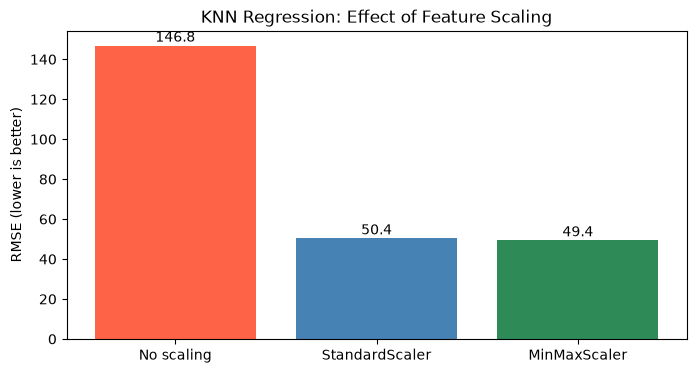

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.bar(
    knn_results_df.index,
    knn_results_df["RMSE"],
    color=["tomato", "steelblue", "seagreen"]
)

plt.ylabel("RMSE (lower is better)")
plt.title("KNN Regression: Effect of Feature Scaling")

for i, value in enumerate(knn_results_df["RMSE"]):
    plt.text(i, value + 2, f"{value:.1f}", ha="center")

plt.show()

### Why does unscaled KNN perform poorly?

KNN often calculates Euclidean distance:

$$ d(x, z) = \sqrt{(x_1-z_1)^2 + (x_2-z_2)^2 + \dots} $$

If one feature has values around `100,000` and another has values around `0.01`, the large feature dominates the calculation.

The model effectively behaves as though the small feature barely exists.

---





# Part 2: Support Vector Regression

Support Vector Regression with an RBF kernel is also sensitive to feature scale.

---

## 7. Compare SVR with and without scaling

SVR can also benefit from scaling the target variable. For simplicity, this example scales the input features only.


In [6]:
from sklearn.svm import SVR

svr_models = {
    "SVR: no scaling": SVR(kernel="rbf", C=100, epsilon=0.1),

    "SVR: StandardScaler": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=100, epsilon=0.1))
    ]),

    "SVR: MinMaxScaler": Pipeline([
            ("scaler", MinMaxScaler()),
            ("svr", SVR(kernel="rbf", C=100, epsilon=0.1))
        ])
}

svr_results = {}

for name, model in svr_models.items():
    svr_results[name] = evaluate_regression(
        model,
        X_train, X_test,
        y_train, y_test
    )

svr_results_df = pd.DataFrame(svr_results).T
print(svr_results_df.round(3))


                         MAE     RMSE     R2
SVR: no scaling      116.385  144.214  0.112
SVR: StandardScaler   23.249   35.860  0.945
SVR: MinMaxScaler     22.986   35.532  0.946


Without feature scaling, the RBF kernel may struggle because its distance calculations are distorted by large-valued features.

---